Shape of Dataset: (1200, 9)
  transaction_date  store_id store_size location_type  promotion_type  \
0       2022-01-01        28      small    semi-urban       free_gift   
1       2022-01-01         5     medium    semi-urban       free_gift   
2       2022-01-02        13      small    semi-urban  loyalty_points   
3       2022-01-02        17      small         urban       free_gift   
4       2022-01-03        50     medium    semi-urban            bogo   

   is_weekend  is_festival  competition_density  items_sold  
0           1            0                    5         224  
1           1            1                    1         348  
2           1            0                    6         249  
3           1            0                    7         259  
4           0            0                    3         277  

Data with New Features:
  transaction_date  store_id store_size location_type  promotion_type  \
0       2022-01-01        28      small    semi-urban       fre

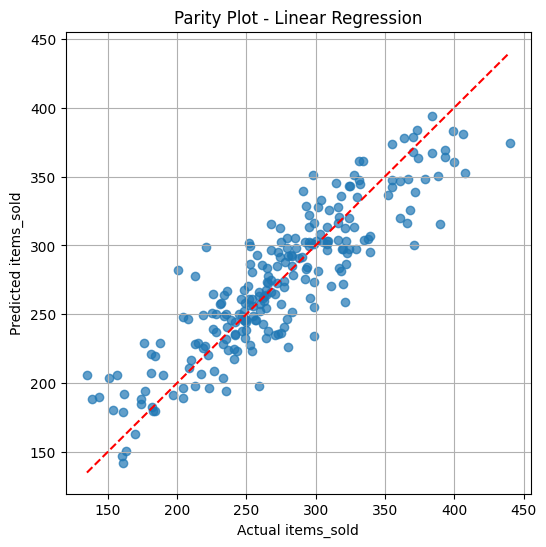


Random Forest
RMSE: 30.74
MAE : 24.22


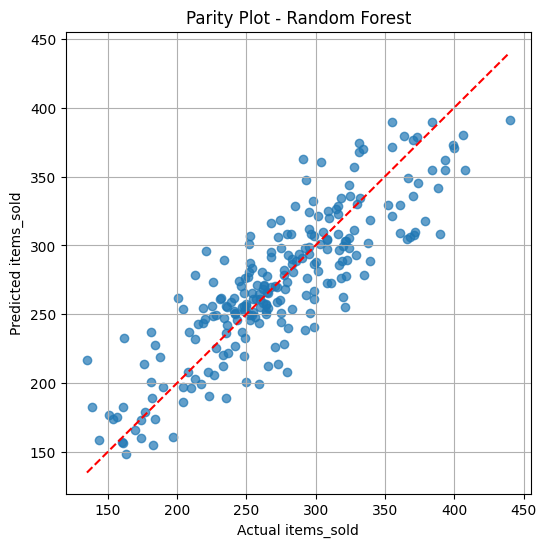


Top 5 Most Influential Features:
                Feature  Importance
13          is_festival    0.176205
10     store_size_small    0.163296
7   location_type_urban    0.112267
17          day_of_week    0.085424
12           is_weekend    0.063098

All Feature Importances:
                          Feature  Importance
13                    is_festival    0.176205
10               store_size_small    0.163296
7             location_type_urban    0.112267
17                    day_of_week    0.085424
12                     is_weekend    0.063098
11                       store_id    0.054079
5             location_type_rural    0.053011
8                store_size_large    0.052743
14            competition_density    0.050145
16                          month    0.037604
0             promotion_type_bogo    0.030804
9               store_size_medium    0.026419
4   promotion_type_loyalty_points    0.022642
15                           year    0.016408
2    promotion_type_flat_discount 

In [5]:

# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_squared_error, mean_absolute_error

# 1. Load Dataset

df = pd.read_csv("../data/q3_retail_promotions.csv")

print("Shape of Dataset:", df.shape)
print(df.head())

# 2. Date Feature Engineering

# Convert to datetime
df["transaction_date"] = pd.to_datetime(df["transaction_date"])

# Extract features
df["year"] = df["transaction_date"].dt.year
df["month"] = df["transaction_date"].dt.month
df["day_of_week"] = df["transaction_date"].dt.dayofweek

# Binary feature
df["is_month_end"] = np.where(
    df["transaction_date"].dt.day >= 25, 1, 0
)

print("\nData with New Features:")
print(df.head())

# 3. Temporal Train-Test Split

df = df.sort_values("transaction_date").reset_index(drop=True)

# 80% train, 20% test
split_index = int(len(df) * 0.80)

train_df = df.iloc[:split_index]
test_df  = df.iloc[split_index:]

print("\nTrain Shape:", train_df.shape)
print("Test Shape :", test_df.shape)

# 4. Features and Target

target = "items_sold"

X_train = train_df.drop(columns=[target, "transaction_date"])
y_train = train_df[target]

X_test = test_df.drop(columns=[target, "transaction_date"])
y_test = test_df[target]

# 5. Preprocessing Pipeline

categorical_cols = [
    "promotion_type",
    "location_type",
    "store_size"
]

numerical_cols = [
    col for col in X_train.columns if col not in categorical_cols
]

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", StandardScaler(), numerical_cols)
    ]
)

# 6. Model Pipelines

models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(
        n_estimators=200,
        random_state=42
    )
}

results = {}

for name, model in models.items():

    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)

    results[name] = (rmse, mae)

    print("\n================================================")
    print(name)
    print("================================================")
    print("RMSE:", round(rmse, 2))
    print("MAE :", round(mae, 2))

    # Parity Plot
    
    plt.figure(figsize=(6,6))
    plt.scatter(y_test, y_pred, alpha=0.7)
    plt.plot(
        [y_test.min(), y_test.max()],
        [y_test.min(), y_test.max()],
        'r--'
    )
    plt.xlabel("Actual items_sold")
    plt.ylabel("Predicted items_sold")
    plt.title(f"Parity Plot - {name}")
    plt.grid(True)
    plt.show()

# 7. Feature Importances (Random Forest)

rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=200,
        random_state=42
    ))
])

rf_pipeline.fit(X_train, y_train)

ohe_features = rf_pipeline.named_steps[
    "preprocessor"
].named_transformers_["cat"].get_feature_names_out(categorical_cols)

all_features = list(ohe_features) + numerical_cols

importances = rf_pipeline.named_steps[
    "model"
].feature_importances_

feature_importance_df = pd.DataFrame({
    "Feature": all_features,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

print("\nTop 5 Most Influential Features:")
print(feature_importance_df.head(5))

print("\nAll Feature Importances:")
print(feature_importance_df)